In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Biblioteca Pandas, series y dataframes

Pandas es una biblioteca de Python muy usada para análisis y manipulación de datos. Provee principalmente dos tipos de clases para trabajar con datos:

- **Series:** un vector unidimensional indexado, que contiene datos de cualquier tipo
como números enteros, cadenas, objetos Python, etc.

- **DataFrame:** una estructura de datos bidimensional que contiene datos como una matriz bidimensional o una tabla con filas y columnas.

Bibliografía recomendada: Sección 5 de Python for Data Analysis, de Wes McKinney (creador de la biblioteca Pandas), disponible on-line en forma gratuita en la página
https://wesmckinney.com/book/pandas-basics

### Series

Las series de Pandas son vectores similares a los arrays de NumPy, que podemos indexar usando etiquetas.

Crear la siguiente Series, observar qué devuelve `values` e `index` e interpretar.

In [7]:
import pandas as pd
enteros = pd.Series([7,4,-5,3])
enteros

,0
0,7
1,4
2,-5
3,3


In [9]:
enteros.values

array([ 7,  4, -5,  3])

In [10]:
enteros.index # Por default, los índices van de 0 a N-1.

RangeIndex(start=0, stop=4, step=1)

Podemos asignar etiquetas (o índices) a cada valor de la serie.

In [11]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)

,0
a,3.141593
b,0.000000
c,-2.000000
d,1.410000


In [12]:
display(reales.values)
display(reales.index)

array([ 3.14159265,  0.        , -2.        ,  1.41      ])

Index(['a', 'b', 'c', 'd'], dtype='object')

Para acceder a los elementos podemos usar las etiquetas.

In [13]:
print(reales["a"])

3.141592653589793


In [14]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)

,0
a,3.141593
b,0.000000
c,-2.000000
d,1.410000


In [15]:
# Acceder por su posición no está recomendado.
reales[1]

/tmp/ipython-input-16164027.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reales[1]


np.float64(0.0)

In [16]:
# Para acceder por su posición usamos iloc
reales.iloc[1]

np.float64(0.0)

In [17]:
# Podemos usar también rangos
reales.iloc[1:3]

,0
b,0.0
c,-2.0


In [18]:
# Para acceder por etiquetas podemos usar también loc
reales.loc["a":"c"]

,0
a,3.141593
b,0.000000
c,-2.000000


In [19]:
# Podemos definir labels numericos
temperaturas = pd.Series([15, 17, 18.2, 25], index = np.array([5, 10, 15, 20]))
print(temperaturas)

5     15.0
10    17.0
15    18.2
20    25.0
dtype: float64


In [20]:
# Que esperamos de los siguientes comandos?
print(temperaturas.iloc[1:3])
print(temperaturas.loc[10:20]) # Por qué??

10    17.0
15    18.2
dtype: float64
10    17.0
15    18.2
20    25.0
dtype: float64


In [21]:
# Funcionará?
temperaturas.iloc[10]

IndexError: single positional indexer is out-of-bounds

In [22]:
# Podemos seleccionar elementos mediante una lista de etiquetas
realesSub = reales[["a","b"]]
print(realesSub)
print(realesSub.index)

a    3.141593
b    0.000000
dtype: float64
Index(['a', 'b'], dtype='object')


## Operaciones con series
Las operaciones que pueden aplicarse a numpy arrays pueden aplicarse también a series de Pandas, conservando los índices.

In [23]:
reales

,0
a,3.141593
b,0.000000
c,-2.000000
d,1.410000


In [24]:
np.exp(reales)

,0
a,23.140693
b,1.000000
c,0.135335
d,4.095955


In [25]:
reales * 3

,0
a,9.424778
b,0.000000
c,-6.000000
d,4.230000


In [26]:
reales > 1

,0
a,True
b,False
c,False
d,True


In [27]:
reales[reales > 1]

,0
a,3.141593
d,1.410000


¿Qué esperamos que dé este código?

In [28]:
print(enteros)
print(reales)

0    7
1    4
2   -5
3    3
dtype: int64
a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64


In [29]:
enteros + reales

,0
0,NaN
1,NaN
2,NaN
3,NaN
a,NaN
b,NaN
c,NaN
d,NaN


NaN significa "not a number", se utiliza en series de Pandas para valores faltantes (missing values).

In [30]:
# Y ahora?
enteros2 = pd.Series([1,2,3,4], index = ["d", "b", "y", "z"])
enteros2

,0
d,1
b,2
y,3
z,4


In [31]:
reales + enteros2

,0
a,NaN
b,2.00
c,NaN
d,2.41
y,NaN
z,NaN


Vemos que solo se suman las filas con índices iguales.

Las series de Pandas tienen varias funciones útiles que iremos viendo más adelante. A modo de ejemplo, interpretar que hacen las siguientes funciones.

In [32]:
series1 = pd.Series(["a", "b", "c", "b", "a", "c", "x"])
series1

,0
0,a
1,b
2,c
3,b
4,a
5,c
6,x


In [33]:
series1.isin(["b", "c"])

,0
0,False
1,True
2,True
3,True
4,False
5,True
6,False


In [34]:
# Pregunta: cómo me quedo solo con las filas con letras "b" o "c"?
series1[series1.isin(["b", "c"])]

,0
1,b
2,c
3,b
5,c


In [35]:
# Qué hace este método?
series1.value_counts()

,count
a,2
b,2
c,2
x,1


### DataFrames
Un data frame es una representación de los datos en formato de tabla en la que cada
columna son vectores del mismo tamaño. Como cada columna es un vector, cada columna puede
contener datos de un único tipo. Se pueden pensar como variables. Cada variable corresponde a una
serie de Pandas, y **todas las series de un dataframe están indexadas por los mismos índices**.

Una forma de crear un data frame es utilizando un "diccionario". Todas las variables del
diccionario deben ser vectores o listas de la misma longitud.

In [36]:
data = {"nombres": ["Rodrigo", "Sergio", "Cristina", "Diana"], "altura": np.array([178, 172, 175, 168]), "peso": np.array
([81.2, 76.1, 68.5, 64.0])}
display(data)

{'nombres': ['Rodrigo', 'Sergio', 'Cristina', 'Diana'],
 'altura': array([178, 172, 175, 168]),
 'peso': array([81.2, 76.1, 68.5, 64. ])}

In [37]:
type(data)

dict

In [38]:
data["peso"]

array([81.2, 76.1, 68.5, 64. ])

In [39]:
# Creamos un data frame con esos datos. Cuáles son los índices?
pacientes = pd.DataFrame(data)
pacientes

,nombres,altura,peso
0,Rodrigo,178,81.2
1,Sergio,172,76.1
2,Cristina,175,68.5
3,Diana,168,64.0


In [40]:
# En este ejemplo podemos usar los nombres como índices
pacientes = pd.DataFrame(data).set_index("nombres")
display(pacientes)

,altura,peso
nombres,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


In [41]:
# Podemos acceder a las columnas de dos formas distintas
alturas = pacientes["altura"]
alturas

,altura
nombres,
Rodrigo,178
Sergio,172
Cristina,175
Diana,168


In [42]:
pacientes.altura

,altura
nombres,
Rodrigo,178
Sergio,172
Cristina,175
Diana,168


In [43]:
type(alturas)

pandas.core.series.Series

In [44]:
alturas.dtype

dtype('int64')

A diferencia de las matrices en Numpy, un DataFrame de Pandas es un conjunto de columnas, no de filas.
Si queremos saber la altura de Rodrigo, pensar cuál de los dos comandos será correcto antes de ejecutarlos.

In [45]:
#Rodrigo no es una columna | pacientes["Rodrigo"].altura

In [46]:
pacientes["altura"].Rodrigo

np.int64(178)

Para acceder a una fila de un dataframe, podemos usar los métodos `loc[]` y `iloc[]`.

¿Cómo se usan? ¿Cuál es la diferencia entre los dos comandos? ¿Que tipo de dato nos devuelve?

In [48]:
pacientes.head()

,altura,peso
nombres,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


In [47]:
pacientes.iloc[3]

,Diana
altura,168.0
peso,64.0


In [50]:
pacientes.loc['Diana']

,Diana
altura,168.0
peso,64.0


## Archivos de datos

La biblioteca Pandas nos permite trabajar fácilmente con archivos de datos.
1. Leer el archivo casos_coronavirus.csv .
2. Graficar la curva de casos por día.
3. Graficar la curva de casos acumulados.
4. Definir log_cum_casos como el logaritmo de la cantidad de casos acumulados y graficar en función de la cantidad de días transcurridos.
5. Estimar, tomando dos valores, la pendiente de la recta para los datos a partir del dia 30.
6. Graficar la recta estimada junto con los datos. ¿Consideran que es una buena estimación?


In [52]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/casos_coronavirus.csv") # DataFrame
df.head()  # Primeras filas del DataFrame

,fecha,confirmados_Nuevos
0,3-3-2020,1
1,4-3-2020,0
2,5-3-2020,1
3,6-3-2020,6
4,7-3-2020,0


In [54]:
# Información básica del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fecha               96 non-null     object
 1   confirmados_Nuevos  96 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [56]:
# ¿Cómo usamos la fecha como índice?
df = df.set_index("fecha")
df

,confirmados_Nuevos
fecha,
3-3-2020,1
4-3-2020,0
5-3-2020,1
6-3-2020,6
7-3-2020,0
...,...
2-6-2020,904
3-6-2020,949
4-6-2020,929


<Axes: xlabel='fecha'>

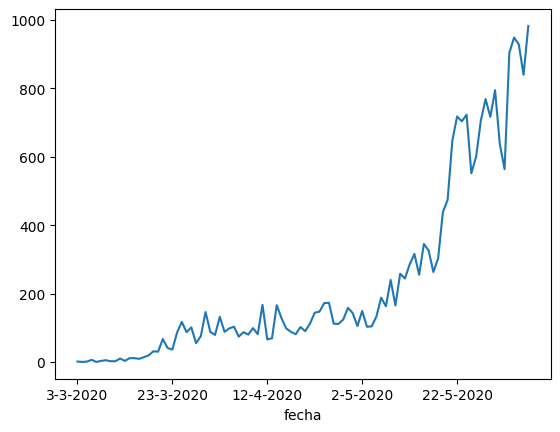

In [57]:
# Graficamos utilizando el método plot de series de Pandas
df["confirmados_Nuevos"].plot()

<Axes: xlabel='fecha'>

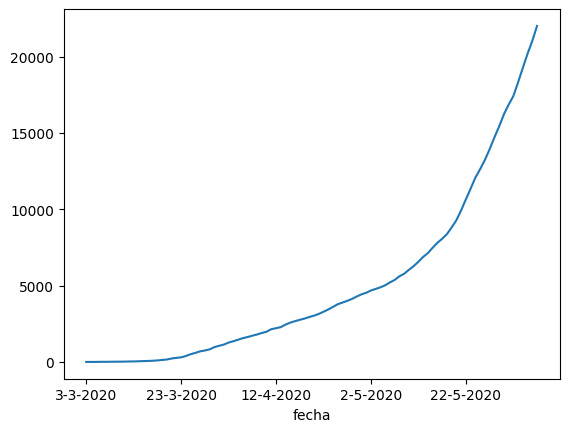

In [58]:
# Queremos graficar los casos acumulados, podemos usar el método cumsum() de series Pandas
df.confirmados_Nuevos.cumsum().plot()

**Ejercicio**
Esta serie presenta un crecimiento exponencial.
Queremos tomar logaritmos para linealizar, ¿como podemos hacerlo?


<Axes: xlabel='fecha'>

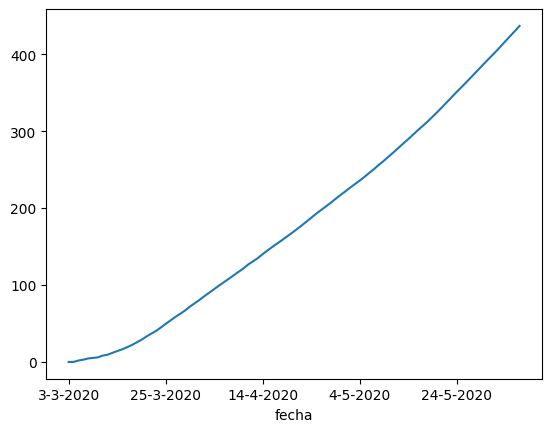

In [59]:
log_cum_casos = np.log(df["confirmados_Nuevos"][df["confirmados_Nuevos"]>0]).cumsum()
log_cum_casos.plot()

**Ejercicio**
Estimar la pendiente de la recta antes del confinamiento (dias 5 al 25) y la pendiente de la recta después del confinamiento.

3.081509768497567


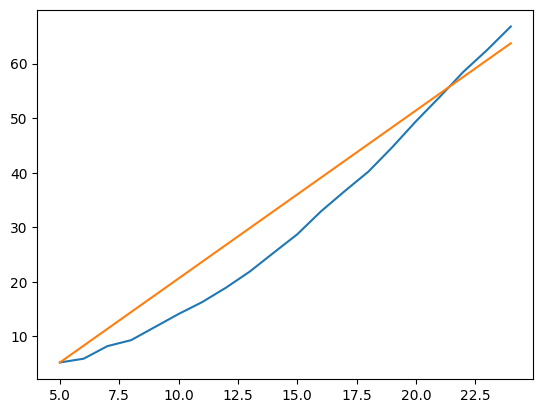

In [131]:
# Agregamos la recta
y_antes = log_cum_casos.iloc[5:25].values
p_antes = (y_antes[-1] - y_antes[0])/20

x_recta = np.arange(5, 25)
y_recta = y_antes[0] + p_antes*(x_recta-x_recta[0])

plt.plot(x_recta, y_antes)
plt.plot(x_recta, y_recta)
print(p_antes)

5.348308584173072


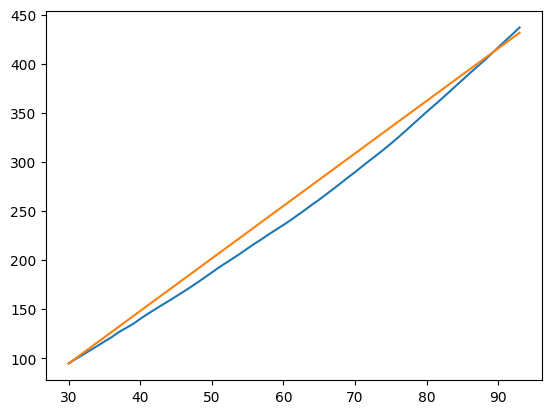

In [132]:
y_despues = log_cum_casos.iloc[30:].values
p_despues = (y_despues[-1] - y_despues[0])/len(y_despues)

x_recta = np.arange(len(y_despues)) + 30
y_recta = y_despues[0] +p_despues*(x_recta-x_recta[0])
plt.plot(x_recta, y_despues)
plt.plot(x_recta, y_recta)
print(p_despues)

## Gapminder

A modo de ejemplo, vamos a explorar el dataset Gapminder que contiene datos poblacionales y de desarrollo humano de distintos países a lo largo del tiempo.

Si gapminder no está instalado, ejecutar el siguiente comando para instalarlo

In [118]:
%pip install gapminder

In [121]:
from gapminder import gapminder

Si les da un error de proxy al instalar paquetes, utilicen estos comandos para eliminar la configuración de proxy:

In [ ]:
# Ejecutar si no funcionó lo de arriba
import os
for k in ["HTTP_PROXY","HTTPS_PROXY","http_proxy","https_proxy"]:
    os.environ.pop(k, None)

Si sigue sin funcionar, pueden descargar gapminder del sitio web:

In [120]:
# Ejecutar si no funcionó lo de arriba
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

In [122]:
# Verificamos si se cargo correctamente
display(gapminder)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


**Pregunta:** Podemos usar alguna columna como índice?

In [123]:
# Para ver las primeras cinco filas
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


Podemos ver información básica del DataFrame con la función info

In [124]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [125]:
# Vemos todos los países en la base
gapminder["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

In [126]:
# Cuántos países son?
gapminder["country"].nunique()

142

### Entrada en calor

1. Cuál era la población de Argentina en 1967? Y la de Brasil?
2. En qué países la expectativa de vida era mayor que 80 años en 2002? Y en 1997? (filtrar la tabla para dejar solo las filas correspondientes)
   

In [139]:
gapminder[(gapminder.country.isin(['Argentina', 'Brazil'])) & (gapminder.year == 1967)]

,country,continent,year,lifeExp,pop,gdpPercap
51,Argentina,Americas,1967,65.634,22934225,8052.953021
171,Brazil,Americas,1967,57.632,88049823,3429.864357


In [140]:
gapminder[(gapminder.year.isin([2002, 1997])) & (gapminder.lifeExp>80)]

,country,continent,year,lifeExp,pop,gdpPercap
70,Australia,Oceania,2002,80.370,19546792,30687.75473
670,"Hong Kong, China",Asia,2002,81.495,6762476,30209.01516
694,Iceland,Europe,2002,80.500,288030,31163.20196
778,Italy,Europe,2002,80.240,57926999,27968.09817
801,Japan,Asia,1997,80.690,125956499,28816.58499
802,Japan,Asia,2002,82.000,127065841,28604.59190
1474,Sweden,Europe,2002,80.040,8954175,29341.63093
1486,Switzerland,Europe,2002,80.620,7361757,34480.95771


### groupby

In [142]:
# Si queremos ver cuántos países hay en cada continente...
# podemos agregupar por continente y ver el tamaño de cada grupo
gapminder.groupby("continent").size()    # Para un dataframe agrupado, size es un método!

,0
continent,
Africa,624
Americas,300
Asia,396
Europe,360
Oceania,24


In [143]:
# Pero cada país aparece varias veces, con datos de distintos años.
# Para contar sin repeticion usamos nuevamente nunique
cantidades = gapminder.groupby("continent")["country"].nunique()
cantidades

,country
continent,
Africa,52
Americas,25
Asia,33
Europe,30
Oceania,2


In [144]:
# Que tipo de dato nos devolvió? Cómo está indexado?
cantidades["Africa"]

np.int64(52)

In [145]:
# Si queremos calcular porcentajes, dividimos por la cantidad total de paises
totalPaises = gapminder["country"].nunique()
totalPaises
gapminder.groupby("continent")["country"].nunique() / totalPaises

,country
continent,
Africa,0.366197
Americas,0.176056
Asia,0.232394
Europe,0.211268
Oceania,0.014085


### value_counts

In [146]:
# O podemos usar el comando value_counts y pasarle un parámetro para que nos de los valores normalizados.
# (la normalización lleva la suma total a 1)
gapminder[["continent", "country"]].drop_duplicates().continent.value_counts(normalize=True)

,proportion
continent,
Africa,0.366197
Asia,0.232394
Europe,0.211268
Americas,0.176056
Oceania,0.014085


In [147]:
# Vemos todos los años disponibles
gapminder["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [148]:
# Tenemos datos de todos los países todos los años?
# Agrupamos los datos por año y calculamos el tamaño de cada bloque
gapminder.groupby("year").size()

,0
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


In [150]:
# Ejercicio: cómo podemos hacerlo utilizando value_counts?
gapminder.year.value_counts()

,count
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


### Gráficos simples de funciones o puntos en el plano XY.
Vamos a graficar la población total mundial en función del año.

In [151]:
pobAnual = gapminder.groupby("year")["pop"].sum()
type(pobAnual)

pandas.core.series.Series

In [152]:
pobAnual

,pop
year,
1952,2406957150
1957,2664404580
1962,2899782974
1967,3217478384
1972,3576977158
1977,3930045807
1982,4289436840
1987,4691477418
1992,5110710260


In [153]:
pobAnual.index

Index([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007], dtype='int64', name='year')

<Axes: xlabel='year'>

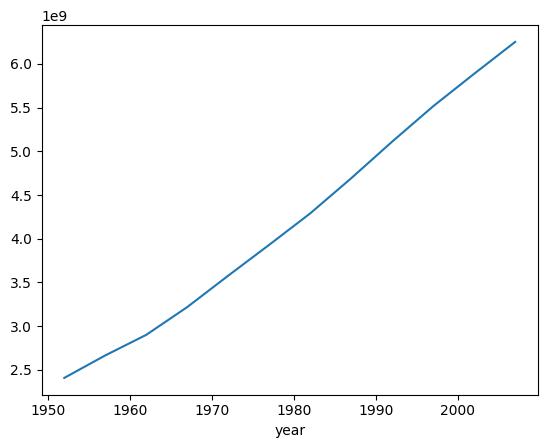

In [154]:
# Opción 1
# Usamos la función plot de series de pandas
pobAnual.plot()

<Axes: xlabel='year'>

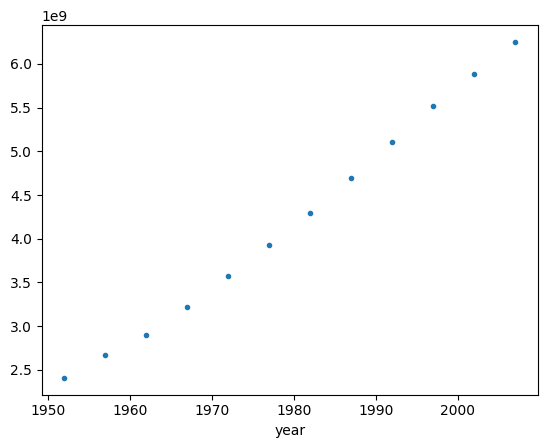

In [155]:
# O podemos graficar solo puntos
pobAnual.plot(style = ".")

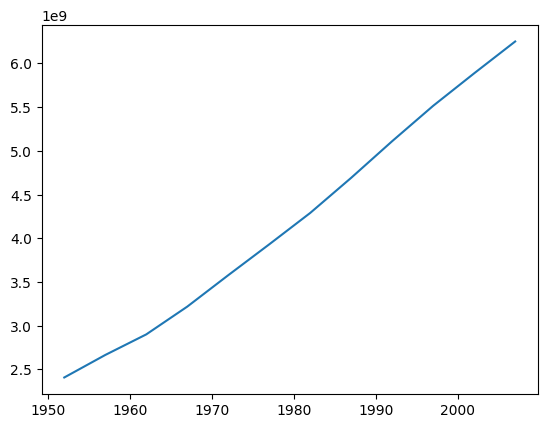

In [156]:
# Opcion 3
# Asignamos los valores a variables (arrays de numpy) y graficamos las variables
x = pobAnual.index
y = pobAnual.values
plt.plot(x,y)

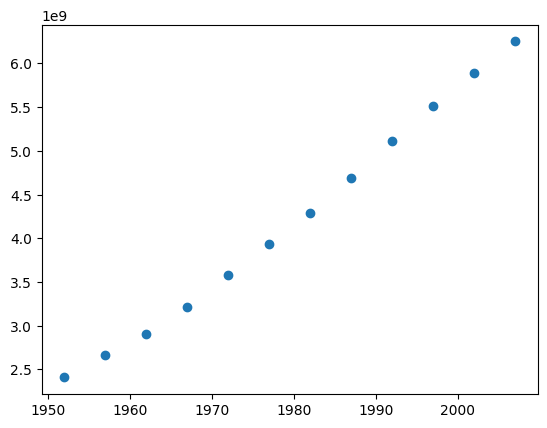

In [157]:
# Opcion 4
# Matplotlib tiene una función scatter para graficar puntos
plt.scatter(x,y)

In [158]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]

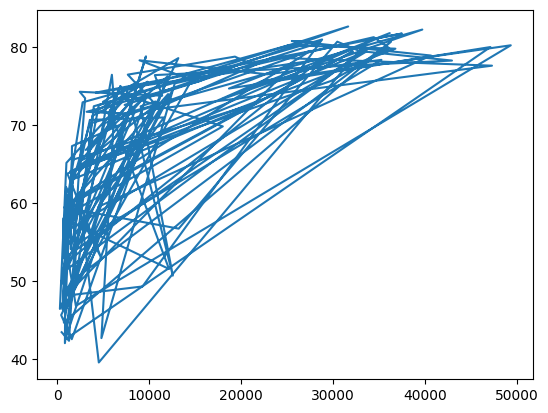

In [159]:
# Queremos ver si hay relación entre el producto bruto y la expectativa de vida
plt.plot(datos2007.gdpPercap, datos2007.lifeExp)

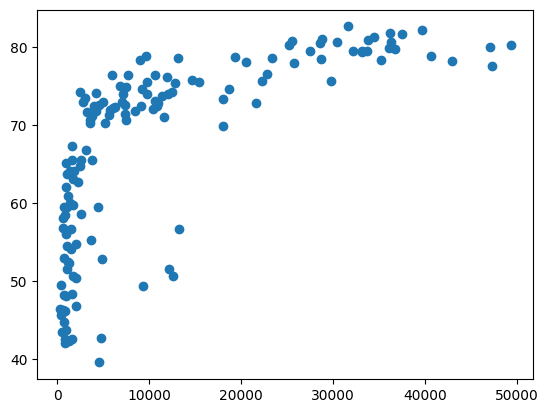

In [160]:
# Ay no, eso no, hacemos un "scatter plot"
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.show()

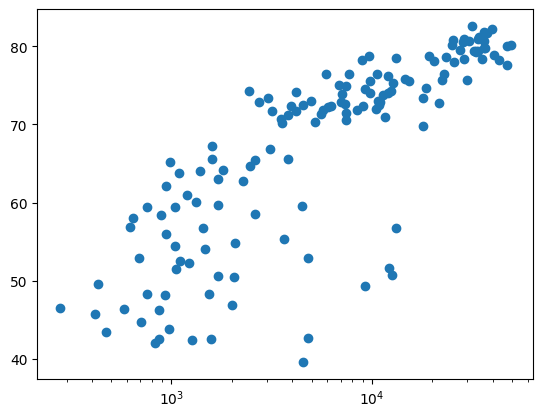

In [ ]:
# Se ve mejor la correlación si usamos escala logaritmica en el eje X
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')

Vamos a mejorar un poco el gráfico

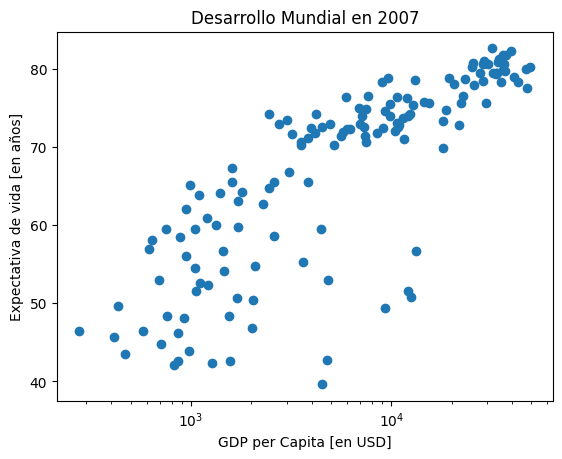

In [ ]:
# Agregamos etiquetas al gráfico y a los ejes
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.show()

Reemplacemos las marcas en el eje $x$ 10³, 10⁴, 10⁵ con 1k, 10k y 100k.

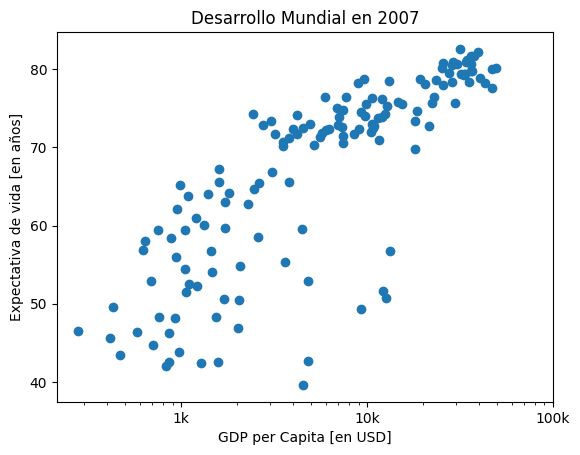

In [ ]:
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

Seaborn es una biblioteca para visualización de datos en Python, basada en Matplotlib que agrega muchas funcioanlidades.

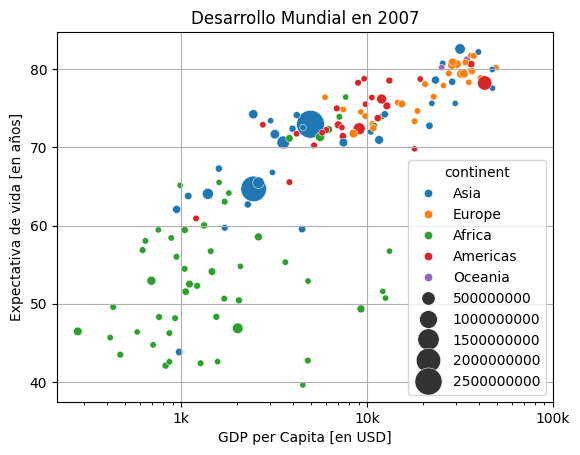

In [ ]:
# Usamos scatterplot de seaborn para poder personalizar mejor el grafico

# Almacenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])

sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop*2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

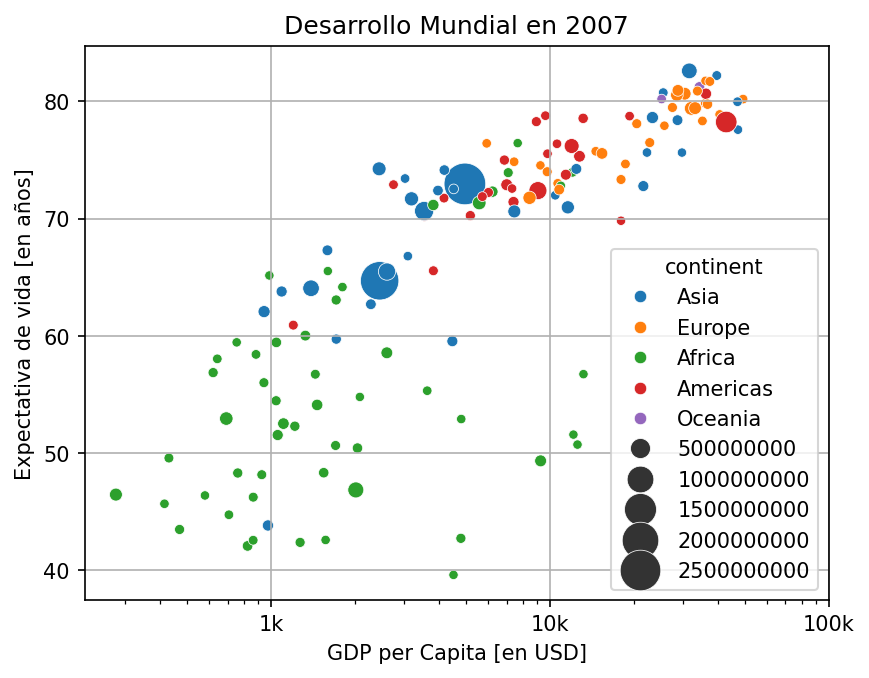

In [ ]:
# Aumenta el tamaño del gráfico
plt.figure(dpi=150)

# Alcenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])
np_pop2 = np_pop*2
# Usamos scatterplot de seaborn para poder personalizar mejor el grafico
sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

## Estadística descriptiva

In [ ]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]
datos2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [ ]:
# Queremos usar los países como índices
datos2007.set_index("country")

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [ ]:
# Funcionó?
datos2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [ ]:
# Para guardar los cambios, lo asignamos a la misma variable
datos2007 = datos2007.set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [ ]:
# O usamos la opcion inplace = True
datos2007 = gapminder[gapminder["year"]==2007]
datos2007.set_index("country", inplace = True)
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [ ]:
# O por último, hacemos todo en una sola linea (opcion recomendada)
datos2007 = gapminder[gapminder["year"]==2007].set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


Mirando los datos de 2007, ¿cuál es el país con mayor expectativa de vida? ¿Cuál es el país con menor expectativa de vida?

In [ ]:
print("País con mayor exp. de vida:", datos2007.index[datos2007.lifeExp.argmax()]) #probar datos2007.index[datos.lifeExp == datos.lifeExp.max()]
print("País con menor exp. de vida:", datos2007.index[datos2007.lifeExp.argmin()])

#idxmax es lo recomendado
#otra opción: datos2007.lifeExp.sort_values()

País con mayor exp. de vida: Japan
País con menor exp. de vida: Swaziland


En matemática, cuando queremos saber para qué valor se alcanza el máximo, decimos que queremos saber el "argumento" del máximo. Esta funcion suele llamarse `argmax`. Utilizar la función de numpy np.argmax para responder las preguntas.

La función de numpy devuelve la posición. Si queremos saber el índice, podemos usar el método de series de Panda idxmax().

In [ ]:
#lo de antes

### Medidas de tendencia central

Para el año 2007, calcular el valor medio y la mediana de las variables gdpPercap y lifeExp entre todos los países.
Son similares o distintas? A qué lo atribuyen? Consideran que alguna resume mejor la realidad que la otra?


In [ ]:
datos2007["lifeExp"].median()

71.93549999999999

In [ ]:
datos2007["lifeExp"].mean()

np.float64(67.00742253521126)

In [ ]:
datos2007["gdpPercap"].median()

6124.3711084999995

In [ ]:
datos2007["gdpPercap"].mean()

np.float64(11680.071819878167)

¿Es lo mismo el promedio de la expectativa de vida entre todos los países y el promedio de la expectativa de vida entre todas las personas?
¿Cuál calculamos arriba? ¿Cómo podemos calcular el otro?


In [ ]:
datos2007_le_country = datos2007.lifeExp.mean()
print('Promedio de la expectativa de vida entre todos los países:', datos2007_le_country)

Promedio de la expectativa de vida entre todos los países: 67.00742253521126


In [ ]:
print('Promedio de la expectativa de vida entre todas las personas:', )

np.float64(71.50214866200466)

### Medidas de dispersión

Para el año 2007, calcular la varianza y el desvío estándar de las variables gdpPercap y lifeExp entre todos los países. ¿Cuál es más fácil de interpretar?

In [ ]:
datos2007["lifeExp"].var()

145.75782404714806

In [ ]:
datos2007["lifeExp"].std()

12.07302050222512